Projet : Pricer d'Options Européennes & Américaines avec Surface de Volatilité

Module 1 : Black-Scholes

In [1]:
from scipy.stats import norm
import numpy as np

def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    S     : prix spot
    K     : strike
    T     : maturité en années
    r     : taux sans risque
    sigma : volatilité
    """
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    return price

def delta(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T) / 100  # en % de vol

Module 2 : Monte Carlo

In [3]:
def monte_carlo_pricer(S, K, T, r, sigma, n_sims=100_000, option_type='call'):
    """
    Simule le GBM : dS = r*S*dt + sigma*S*dW
    avec antithetic variates pour réduire la variance
    """
    Z = np.random.standard_normal(n_sims // 2)
    Z = np.concatenate([Z, -Z])  # antithetic
    
    ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    if option_type == 'call':
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)
    
    price = np.exp(-r*T) * np.mean(payoffs)
    std_err = np.exp(-r*T) * np.std(payoffs) / np.sqrt(n_sims)
    
    return price, std_err  # toujours retourner l'IC !

Module 3 : Arbre binomial CRR

In [4]:
def crr_binomial(S, K, T, r, sigma, N=200, option_type='call', american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))   # facteur hausse
    d = 1 / u                          # facteur baisse
    p = (np.exp(r*dt) - d) / (u - d)  # proba risque-neutre
    
    # Valeurs terminales
    ST = S * u**np.arange(N, -1, -1) * d**np.arange(0, N+1)
    if option_type == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)
    
    # Backward induction
    for i in range(N-1, -1, -1):
        V = np.exp(-r*dt) * (p*V[:-1] + (1-p)*V[1:])
        if american:
            ST_node = S * u**np.arange(i, -1, -1) * d**np.arange(0, i+1)
            intrinsic = np.maximum(ST_node - K, 0) if option_type=='call' \
                        else np.maximum(K - ST_node, 0)
            V = np.maximum(V, intrinsic) 
    
    return V[0]

Module 4 : Volatilité implicite & surface 

In [6]:
from scipy.optimize import brentq

def implied_vol(market_price, S, K, T, r, option_type='call'):
    """Inversion numérique de Black-Scholes par méthode de Brent"""
    try:
        iv = brentq(
            lambda sigma: black_scholes(S, K, T, r, sigma, option_type) - market_price,
            1e-6, 10.0,  # bornes de recherche
            xtol=1e-6
        )
        return iv
    except ValueError:
        return np.nan  # prix hors bornes d'arbitrage

In [7]:
import yfinance as yf
import pandas as pd

ticker = yf.Ticker("AAPL")
S = ticker.history(period="1d")['Close'].iloc[-1]

records = []
for exp in ticker.options[:5]:  # 5 maturités
    chain = ticker.option_chain(exp)
    for _, row in chain.calls.iterrows():
        T = (pd.Timestamp(exp) - pd.Timestamp.today()).days / 365
        iv = implied_vol(row['lastPrice'], S, row['strike'], T, r=0.05)
        records.append({'strike': row['strike'], 'T': T, 'iv': iv})

df = pd.DataFrame(records).dropna()

/tmp/ipykernel_26716/3497799856.py:12: RuntimeWarning: invalid value encountered in sqrt
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
/tmp/ipykernel_26716/3497799856.py:13: RuntimeWarning: invalid value encountered in sqrt
  d2 = d1 - sigma*np.sqrt(T)


In [12]:
print(df[['strike', 'T', 'iv']].shape)
print(df[['strike', 'T', 'iv']].isna().sum())

(213, 3)
strike    0
T         0
iv        0
dtype: int64


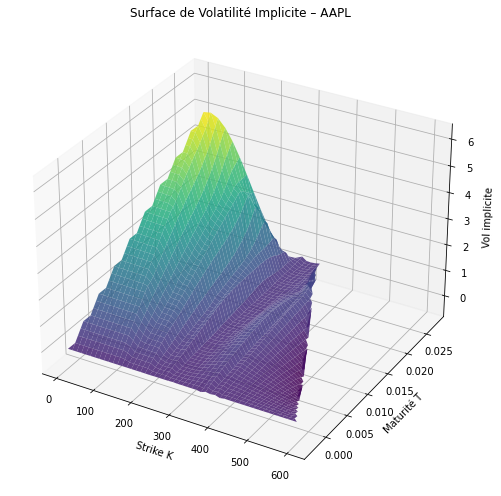

In [14]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df_clean = df[['strike', 'T', 'iv']].dropna().rename(columns={'T': 'maturity'})

# Grille régulière
K_grid = np.linspace(df_clean['strike'].min(), df_clean['strike'].max(), 50)
T_grid = np.linspace(df_clean['maturity'].min(), df_clean['maturity'].max(), 50)
KK, TT = np.meshgrid(K_grid, T_grid)

points = np.column_stack([df_clean['strike'].values, df_clean['maturity'].values])
values = df_clean['iv'].values

IV_grid = griddata(points, values, (KK, TT), method='cubic')

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(KK, TT, IV_grid, cmap='viridis', alpha=0.85)
ax.set_xlabel('Strike K')
ax.set_ylabel('Maturité T')
ax.set_zlabel('Vol implicite')
ax.set_title('Surface de Volatilité Implicite – AAPL')
plt.tight_layout()
plt.show()